In [100]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/irisdataset/Iris.csv


In [101]:
df = pd.read_csv("/kaggle/input/irisdataset/Iris.csv")

In [102]:
df.head()

,petal_length,petal_width,sepal_length,sepal_width,label
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


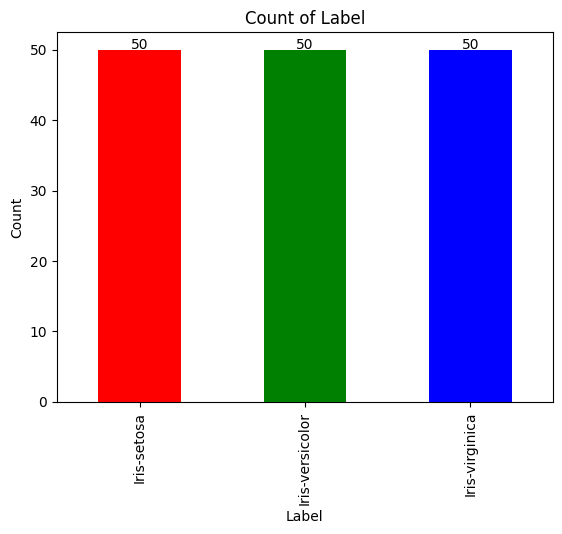

In [103]:
import matplotlib.pyplot as plt

# Bar plot
ax = df['label'].value_counts().plot(kind='bar', color=['red', 'green', 'blue'])
plt.xlabel('Label')
plt.ylabel('Count')
plt.title('Count of Label')

# Add count labels on top of bars
for p in ax.patches:
    ax.text(
        p.get_x() + p.get_width() / 2,  
        p.get_height() + 0.1,       
        int(p.get_height()),  
        ha='center'
    )

plt.show()

In [104]:
classes = np.unique(-1)
classes

array([-1])

In [105]:
df = pd.get_dummies(df, columns=['label'], dtype=int)
df.head()

,petal_length,petal_width,sepal_length,sepal_width,label_Iris-setosa,label_Iris-versicolor,label_Iris-virginica
0,5.1,3.5,1.4,0.2,1,0,0
1,4.9,3.0,1.4,0.2,1,0,0
2,4.7,3.2,1.3,0.2,1,0,0
3,4.6,3.1,1.5,0.2,1,0,0
4,5.0,3.6,1.4,0.2,1,0,0


In [106]:
df1 = df.iloc[:, 0:5]
df1.head()

,petal_length,petal_width,sepal_length,sepal_width,label_Iris-setosa
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,1
2,4.7,3.2,1.3,0.2,1
3,4.6,3.1,1.5,0.2,1
4,5.0,3.6,1.4,0.2,1


In [107]:
df2 = pd.concat([df.iloc[:, 0:4], df.iloc[:, [5]]], axis=1)
df2.sample(5)

,petal_length,petal_width,sepal_length,sepal_width,label_Iris-versicolor
45,4.8,3.0,1.4,0.3,0
105,7.6,3.0,6.6,2.1,0
30,4.8,3.1,1.6,0.2,0
2,4.7,3.2,1.3,0.2,0
73,6.1,2.8,4.7,1.2,1


In [108]:
df3 = pd.concat([df.iloc[:, 0:4], df.iloc[:, [-1]]], axis=1)
df3.sample(5)

,petal_length,petal_width,sepal_length,sepal_width,label_Iris-virginica
145,6.7,3.0,5.2,2.3,1
60,5.0,2.0,3.5,1.0,0
36,5.5,3.5,1.3,0.2,0
41,4.5,2.3,1.3,0.3,0
98,5.1,2.5,3.0,1.1,0


In [109]:
models = []

In [110]:
X_train = df.iloc[:, 0:4]
X_train.head()

,petal_length,petal_width,sepal_length,sepal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [111]:
y_train_model1 = df1.iloc[:, -1]
y_train_model1.head()

0    1
1    1
2    1
3    1
4    1
Name: label_Iris-setosa, dtype: int64

In [112]:
y_train_model2 = df2.iloc[:, -1]
y_train_model2.head()

0    0
1    0
2    0
3    0
4    0
Name: label_Iris-versicolor, dtype: int64

In [113]:
y_train_model3 = df3.iloc[:, -1]
y_train_model3.head()

0    0
1    0
2    0
3    0
4    0
Name: label_Iris-virginica, dtype: int64

# Train Logistic Regression to Dataset 1

In [114]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [115]:
X_train1, X_test1, y_train1, y_test1 = train_test_split(X_train, y_train_model1.values, test_size=0.3, random_state=42)

In [116]:
model1 = LogisticRegression(max_iter=500)
model1.fit(X_train1, y_train1)
models.append(model1)

In [117]:
models

[LogisticRegression(max_iter=500)]

# Train Logistic Regression to Dataset 2

In [118]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_train, y_train_model2.values, test_size=0.3, random_state=42)

In [119]:
model2 = LogisticRegression(max_iter=500)
model2.fit(X_train2, y_train2)
models.append(model2)

In [120]:
models

[LogisticRegression(max_iter=500), LogisticRegression(max_iter=500)]

# Train Logistic Regression to Dataset 3

In [121]:
X_train3, X_test3, y_train3, y_test3 = train_test_split(X_train, y_train_model3.values, test_size=0.3, random_state=42)

In [122]:
model3 = LogisticRegression(max_iter=500)
model3.fit(X_train3, y_train3)
models.append(model3)

In [123]:
models

[LogisticRegression(max_iter=500),
 LogisticRegression(max_iter=500),
 LogisticRegression(max_iter=500)]

# Predict probabilities for each class

In [124]:
probas = np.column_stack([model.predict_proba(X_test)[:, 1] for model in models])

In [125]:
probas

array([[4.84313598e-03, 5.31020136e-01, 2.13486047e-01],
       [9.51268754e-01, 5.82256403e-02, 1.30370013e-05],
       [6.69568369e-06, 5.93551351e-01, 9.98133461e-01],
       [6.44942052e-03, 3.86003073e-01, 2.23305055e-01],
       [2.42938077e-03, 4.58518092e-01, 2.99868798e-01],
       [9.57195574e-01, 1.14885128e-01, 1.18554812e-05],
       [6.04962072e-02, 3.36102581e-01, 1.98550935e-02],
       [6.96923872e-04, 1.78408777e-01, 8.29504135e-01],
       [3.31697051e-03, 7.36316556e-01, 2.60037475e-01],
       [2.78528377e-02, 4.92948044e-01, 3.59226058e-02],
       [1.17468345e-03, 2.01834453e-01, 7.44247916e-01],
       [9.71082626e-01, 3.09572728e-01, 6.94404334e-06],
       [9.77259856e-01, 9.92207395e-02, 4.41125852e-06],
       [9.65737853e-01, 2.71077460e-01, 8.46256489e-06],
       [9.74856762e-01, 5.96310054e-02, 9.15472514e-06],
       [4.71102414e-03, 1.98844555e-01, 3.19466446e-01],
       [1.83113210e-04, 3.23192728e-01, 9.67179201e-01],
       [2.80681155e-02, 6.34048

# Choose the class with the highest probability

In [126]:
y_pred_indices = np.argmax(probas, axis=1)
y_true_indices = np.argmax(y_test, axis=1)

NameError: name 'y_test' is not defined